In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import random 
import scipy.stats as stats
import seaborn as sns
from IPython.core.debugger import set_trace
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras import backend as K
from collections import namedtuple, deque
import warnings
warnings.filterwarnings('ignore')

In [34]:
def monte_carlo_paths(S_0, time_to_expiry, sigma, drift, seed, n_sims, n_timesteps):
    if seed > 0:
        np.random.seed(seed)
    stdnorm_random_variates = np.random.randn(n_sims, n_timesteps)
    S = S_0
    dt = time_to_expiry / stdnorm_random_variates.shape[1]
    r = drift
    S_T = S * np.cumprod(np.exp((r-sigma**2/2)* dt + sigma * np.sqrt(dt) * stdnorm_random_variates), axis= 1)
    return np.reshape(np.transpose(np.c_[np.ones(n_sims) * S_0, S_T]), (n_timesteps + 1, n_sims, 1))

In [35]:
S_0 = 100
K = 100
r = 0
vol = 0.2
T = 1/12
timesteps = 30
seed = 42
n_sims = 50000

In [36]:
paths_train = monte_carlo_paths(S_0, T, vol, r, seed, n_sims, timesteps)

# Exploratory Data Analysis

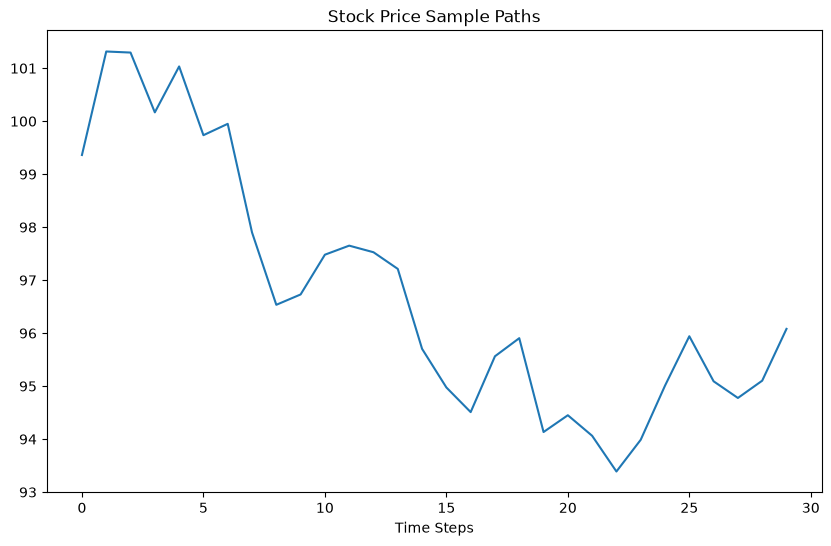

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(paths_train[1:31, 1])
plt.xlabel('Time Steps')
plt.title('Stock Price Sample Paths')
plt.show()

# Implementing in the RL (AR) "Agent" class

In [38]:
class Agent(object):
    def __init__(self, time_steps, batch_size, features, nodes = [64, 46, 46, 1], name = 'model'):
        tf.reset.default_graph()
        self.batch_size = batch_size # número de opcoes em um lote
        self.S_t_input = tf.placeholder(tf.float32, [time_steps, batch_size, features]) # spot
        self.K = tf.placeholder(tf.float32, batch_size) # strike
        self.alpha = tf.placeholder(tf.float32) # alpha para CVar

        S_T = self.S_t_input[-1,:,0] # spot no tempo T
        dS = self.S_t_input[1:, :, 0] - self.S_t_input[0:-1, :, 0]

        S_t = tf.unstack(self.S_t_input[:-1, :, :], axis= 0)

        # criar LSTM
        lstm = tf.contrib.rnn.MultRNNCell([tf.contrib.rnn.LSTMCell(n) for n in nodes])
        self.strategy = tf.nn.static_rnn(lstm, S_t, initial_state= lstm.zero_state(batch_size, tf.float32), dtype= tf.float32)
        self.strategy = tf.reshape(self.strategy, (time_steps - 1, batch_size))

        # preco da opcao
        self.option = tf.maximum(S_T - self.K, 0)
        self.Hedging_PnL = - self.option + tf.reduce_sum(dS * self.strategy, axis= 0)

        # hedge total do PnL de cada caminho
        self.Hedging_PnL_Paths = - self.option + dS * self.strategy

        # calculo do CVar para determinado nível de confiança alpha
        # pegar os principais PnL negativos e calcular a média
        CVaR, idx = tf.nn.top_k(- self.Hedging_PnL, tf.cast((1 - self.alpha) * batch_size, tf.int32))
        CVaR = tf.reduce_mean(CVaR)
        self.train = tf.train.AdamOptimizer().minimize(CVaR)
        self.saver = tf.train.Saver()
        self.modelname = name
        